# Chemistry Utility Visualization

Visualizes chemistry utility results from `chemistry_utility_cache/` output by `script_2026_01_23_evaluate_subject_utility.py`.

In [7]:
import json
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Load the overview JSON
cache_path = Path("chemistry_utility_cache_gpt-5.2/chemistry_utility_cache_overview.json") # Newer judge to see if "smarter" => more seperation between our thing and the scoped model (i.e. nano model may not be super smart)
# cache_path = Path("chemistry_utility_cache_gpt-4.1-nano/chemistry_utility_cache_overview.json") # Cheaper judge that we used historically
with open(cache_path) as f:
    data = json.load(f)

results = data["results"]
print(f"Loaded {len(results)} results")

Loaded 11 results


In [9]:
def classify_model_type(model_name_or_path: str) -> str:
    """Classify model into type based on path."""
    if model_name_or_path == "google/gemma-2-9b-it":
        return "Vanilla"
    if "/vanilla/" in model_name_or_path:
        return "SFT"
    if "/chemistry/" in model_name_or_path:
        return "SAE-Enhanced (Chemistry)"
    if "/ultrachat/" in model_name_or_path:
        return "SAE-Enhanced (Ultrachat)"
    return "Unknown"


def extract_step(model_name_or_path: str) -> int:
    """Extract checkpoint step from path."""
    match = re.search(r"checkpoint-(\d+)", model_name_or_path)
    if match:
        return int(match.group(1))
    return 0


def get_short_name(model_name_or_path: str) -> str:
    """Get a short display name for the model."""
    model_type = classify_model_type(model_name_or_path)
    step = extract_step(model_name_or_path)
    if model_type == "Vanilla":
        return "Vanilla"
    if model_type == "SFT":
        return f"SFT-{step}"
    if model_type == "SAE-Enhanced (Chemistry)":
        return f"SAE-Chem-{step}"
    if model_type == "SAE-Enhanced (Ultrachat)":
        return f"SAE-Ultra-{step}"
    return model_name_or_path

In [10]:
# Parse results into structured data
parsed_results = []
for r in results:
    model_path = r["kwargs"]["model_name_or_path"]
    parsed_results.append({
        "model_path": model_path,
        "model_type": classify_model_type(model_path),
        "short_name": get_short_name(model_path),
        "step": extract_step(model_path),
        "utility_overall": r["data_dict"]["utility/overall"],
        "utility_answering": r["data_dict"]["utility/answering"],
        "utility_factual_helpful": r["data_dict"]["utility/factual_helpful"],
        "utility_precise": r["data_dict"]["utility/precise"],
    })

# Sort by type, then by step
type_order = ["Vanilla", "SFT", "SAE-Enhanced (Chemistry)", "SAE-Enhanced (Ultrachat)"]
parsed_results.sort(key=lambda x: (type_order.index(x["model_type"]) if x["model_type"] in type_order else 99, x["step"]))

for r in parsed_results:
    print(f"{r['short_name']:20} ({r['model_type']:25}) utility={r['utility_overall']:.4f}")

Vanilla              (Vanilla                  ) utility=0.6432
SFT-1000             (SFT                      ) utility=0.5599
SFT-2000             (SFT                      ) utility=0.6797
SFT-3000             (SFT                      ) utility=0.6693
SFT-4000             (SFT                      ) utility=0.6693
SAE-Chem-1000        (SAE-Enhanced (Chemistry) ) utility=0.5755
SAE-Chem-2000        (SAE-Enhanced (Chemistry) ) utility=0.6120
SAE-Chem-3000        (SAE-Enhanced (Chemistry) ) utility=0.5755
SAE-Chem-4000        (SAE-Enhanced (Chemistry) ) utility=0.5469
SAE-Ultra-1000       (SAE-Enhanced (Ultrachat) ) utility=0.2604
SAE-Ultra-2000       (SAE-Enhanced (Ultrachat) ) utility=0.2943


In [11]:
# Color mapping by model type
type_colors = {
    "Vanilla": "#4C72B0",               # Blue
    "SFT": "#55A868",                    # Green
    "SAE-Enhanced (Chemistry)": "#C44E52",  # Red
    "SAE-Enhanced (Ultrachat)": "#8172B3",  # Purple
    "Unknown": "#CCB974",                # Yellow
}

# Prepare data for plotting
names = [r["short_name"] for r in parsed_results]
utilities = [r["utility_overall"] for r in parsed_results]
colors = [type_colors[r["model_type"]] for r in parsed_results]

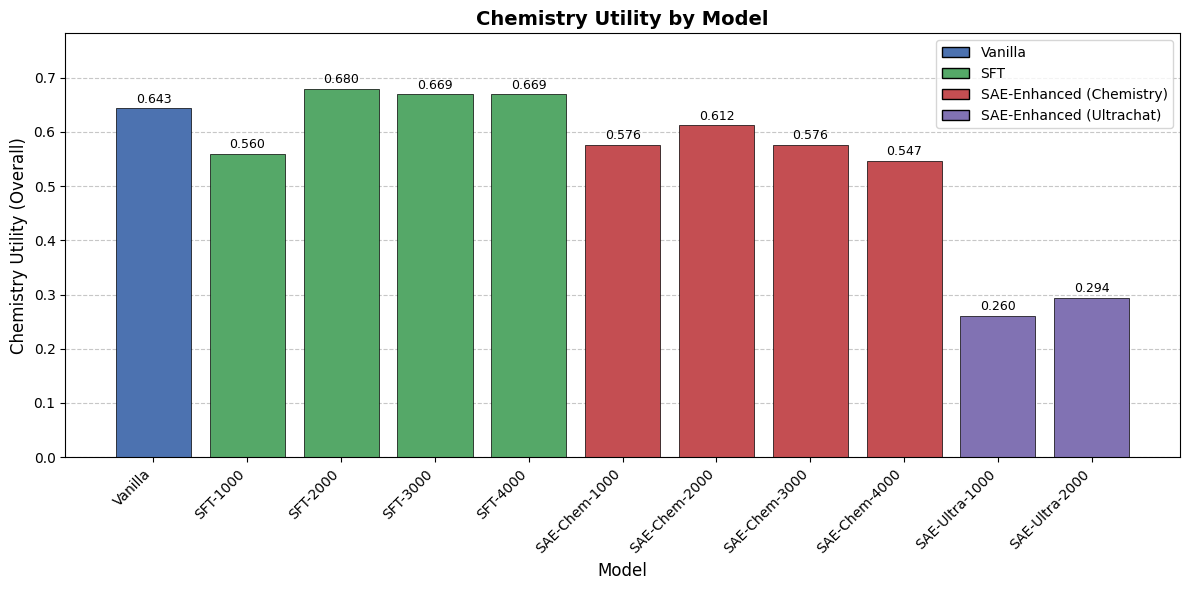

In [12]:
# Create the bar plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(names))
bars = ax.bar(x, utilities, color=colors, edgecolor="black", linewidth=0.5)

# Customize the plot
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Chemistry Utility (Overall)", fontsize=12)
ax.set_title("Chemistry Utility by Model", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=10)
ax.set_ylim(0, max(utilities) * 1.15)  # Add some headroom

# Add value labels on bars
for bar, util in zip(bars, utilities):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{util:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Create legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, edgecolor="black", label=model_type)
    for model_type, color in type_colors.items()
    if model_type in [r["model_type"] for r in parsed_results]
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

# Grid for readability
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("chemistry_utility_bar_plot.png", dpi=150, bbox_inches="tight")
plt.show()

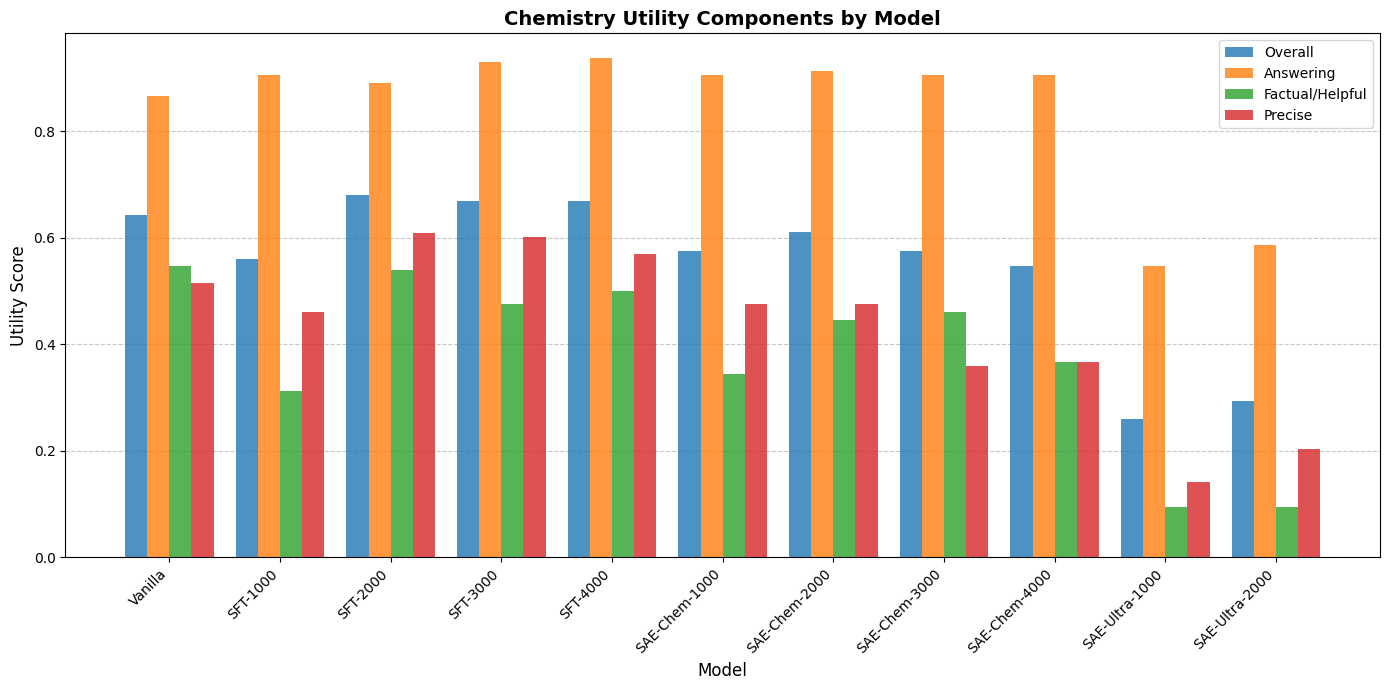

In [13]:
# Grouped bar chart showing all utility components
fig, ax = plt.subplots(figsize=(14, 7))

utility_types = ["utility_overall", "utility_answering", "utility_factual_helpful", "utility_precise"]
utility_labels = ["Overall", "Answering", "Factual/Helpful", "Precise"]
n_utilities = len(utility_types)
bar_width = 0.2

x = np.arange(len(names))

for i, (util_key, util_label) in enumerate(zip(utility_types, utility_labels)):
    values = [r[util_key] for r in parsed_results]
    offset = (i - n_utilities / 2 + 0.5) * bar_width
    ax.bar(x + offset, values, bar_width, label=util_label, alpha=0.8)

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Utility Score", fontsize=12)
ax.set_title("Chemistry Utility Components by Model", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=10)
ax.legend(loc="upper right", fontsize=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("chemistry_utility_components_bar_plot.png", dpi=150, bbox_inches="tight")
plt.show()